In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd

In [10]:
file_name = 'Real_Estate_Sales_2001-2023_GL.csv'
gdf = gpd.read_file(file_name)

In [11]:
gdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1141722 entries, 0 to 1141721
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Serial Number     1141722 non-null  object
 1   List Year         1141722 non-null  object
 2   Date Recorded     1141722 non-null  object
 3   Town              1141722 non-null  object
 4   Address           1141722 non-null  object
 5   Assessed Value    1141722 non-null  object
 6   Sale Amount       1141722 non-null  object
 7   Sales Ratio       1141722 non-null  object
 8   Property Type     1141722 non-null  object
 9   Residential Type  1141722 non-null  object
 10  Non Use Code      1141722 non-null  object
 11  Assessor Remarks  1141722 non-null  object
 12  OPM remarks       1141722 non-null  object
 13  Location          1141722 non-null  object
dtypes: object(14)
memory usage: 121.9+ MB


In [12]:
gdf.head(5)

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,133000.00,248400.00,0.5354,Residential,Single Family,,,,POINT (-73.06822 41.35014)
1,2020225,2020,05/26/2021,Ansonia,152 JACKSON ST,110500.00,239900.00,0.4606,Residential,Three Family,,,,
2,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,150500.00,325000.00,0.463,Commercial,,,,,
3,2020090,2020,12/14/2020,Ansonia,57 PLATT ST,127400.00,202500.00,0.6291,Residential,Two Family,,,,
4,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,179990.00,362500.00,0.4965,Residential,Condo,,,,POINT (-72.879115982 41.773452988)


In [35]:
value_counts = gdf['List Year'].value_counts().sort_index(ascending=False)
value_counts

,count
List Year,
2023,44093
2022,43470
2021,56946
2020,66592
2019,58954
2018,50709
2017,45691
2016,49773
2015,46651


In [38]:
gdf[['List Year', 'Location']]

,List Year,Location
0,2020,POINT (-73.06822 41.35014)
1,2020,
2,2020,
3,2020,
4,2021,POINT (-72.879115982 41.773452988)
...,...,...
1141717,2023,POINT (-72.86373 41.56032)
1141718,2023,POINT (-72.97401 41.24665)
1141719,2023,POINT (-72.88193 41.62094)
1141720,2023,POINT (-72.30557 41.29054)


In [74]:
gdf_clean = gdf

In [75]:
gdf_clean['Location'] = gdf_clean['Location'].replace(['null', 'None', '', 'N/A'], pd.NA)
gdf_clean = gdf_clean.dropna(subset=['Location'])

In [76]:
gdf_clean

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,133000.00,248400.00,0.5354,Residential,Single Family,,,,POINT (-73.06822 41.35014)
4,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,179990.00,362500.00,0.4965,Residential,Condo,,,,POINT (-72.879115982 41.773452988)
6,200121,2020,12/15/2020,Avon,63 NORTHGATE,528490.00,775000.00,0.6819,Residential,Single Family,,,,POINT (-72.89675 41.79445)
24,211386,2021,04/18/2022,Bridgeport,55 CANNON ST,110610.00,50000.00,2.2122,Vacant Land,,,,,POINT (-73.19020596 41.178257983)
29,200207,2020,11/23/2020,Bristol,BROAD PLACE LOTS 225-6 AND 224,8400.00,38500.00,0.2181,Vacant Land,,25 - Other,MULTIPLE LOT SALE,,POINT (-72.90406 41.66996)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141717,230299,2023,04/19/2024,Southington,580-23 MERIDEN WATERBURY TPKE,26540.00,509900.00,0.0520,Residential,Condo,07 - Change in Property,NEW CONSTRUCTION OVER 55 CONDO,,POINT (-72.86373 41.56032)
1141718,230568,2023,05/15/2024,West Haven,165 MILTON AVE,148050.00,400300.00,0.3698,Residential,Single Family,,,,POINT (-72.97401 41.24665)
1141719,230217,2023,02/20/2024,Southington,242 LAZY LN,177340.00,334750.00,0.5297,Residential,Single Family,,,,POINT (-72.88193 41.62094)
1141720,230097,2023,05/30/2024,Old Lyme,21 BUTTONBALL RD,8030.00,35000.00,0.2294,Vacant Land,,,DEVELOPERS LOT FOR NEW CONST,,POINT (-72.30557 41.29054)


In [77]:
plt.rcParams['figure.dpi']=150

In [78]:
numeric_cols = []
for col in gdf_clean.columns:
    try:
        gdf_clean[col] = pd.to_numeric(gdf[col])
        if gdf_clean[col].dtype in ['float64', 'int64', 'Int64']:
            numeric_cols.append(col)
    except:
        pass

/tmp/ipython-input-467/3247089485.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_clean[col] = pd.to_numeric(gdf[col])


In [79]:
numeric_cols

['Serial Number', 'List Year', 'Assessed Value', 'Sale Amount']

In [80]:
gdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 341241 entries, 0 to 1141721
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Serial Number     341241 non-null  int64  
 1   List Year         341241 non-null  int64  
 2   Date Recorded     341241 non-null  object 
 3   Town              341241 non-null  object 
 4   Address           341241 non-null  object 
 5   Assessed Value    341241 non-null  float64
 6   Sale Amount       341241 non-null  float64
 7   Sales Ratio       341241 non-null  object 
 8   Property Type     341241 non-null  object 
 9   Residential Type  341241 non-null  object 
 10  Non Use Code      341241 non-null  object 
 11  Assessor Remarks  341241 non-null  object 
 12  OPM remarks       341241 non-null  object 
 13  Location          341241 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 39.1+ MB


In [89]:
gdf_clean['Date Recorded'] = pd.to_datetime(gdf_clean['Date Recorded'],format='%m/%d/%Y', errors='coerce')

/tmp/ipython-input-467/758752936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_clean['Date Recorded'] = pd.to_datetime(gdf_clean['Date Recorded'],format='%m/%d/%Y', errors='coerce')


In [93]:
gdf_clean.loc[6231]

,6231
Serial Number,200630
List Year,2020
Date Recorded,2021-03-22 00:00:00
Town,Manchester
Address,52 FALKNOR DRIVE
Assessed Value,105800.0
Sale Amount,237000.0
Sales Ratio,0.4464
Property Type,Residential
Residential Type,Single Family


<Axes: >

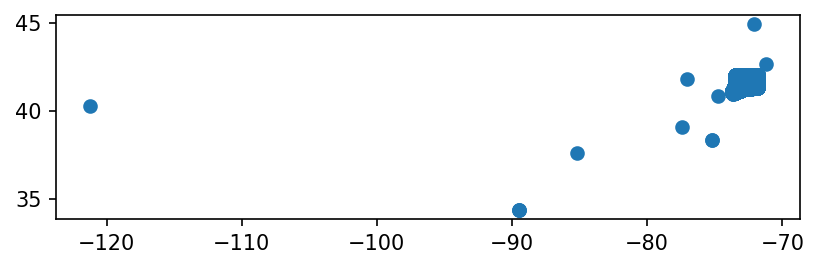

In [104]:
from shapely import wkt
from shapely.geometry import Point
import datetime as dt

# Step 1: Robustly filter Date Recorded to ensure it's within Matplotlib's accepted range
start_date = dt.datetime(1, 1, 1)
end_date = dt.datetime(9999, 12, 31)

gdf_clean_filtered_dates = gdf_clean[
    (gdf_clean['Date Recorded'] >= start_date)
    & (gdf_clean['Date Recorded'] <= end_date)
].copy()

# Step 2: Convert 'Location' strings to shapely Point objects and set geometry
# Only apply to non-null Location values that are strings
gdf_clean_filtered_dates['geometry'] = gdf_clean_filtered_dates['Location'].apply(lambda x: wkt.loads(x) if pd.notna(x) and isinstance(x, str) else None)

# Drop rows where geometry could not be parsed or was null
gdf_clean_filtered_dates = gdf_clean_filtered_dates.dropna(subset=['geometry'])

# Explicitly ensure it's a GeoDataFrame with the correct geometry column and CRS.
# Assuming WGS84 (EPSG:4326) for latitude and longitude coordinates.
gdf_clean_filtered_dates = gpd.GeoDataFrame(gdf_clean_filtered_dates, geometry='geometry', crs="EPSG:4326")

# Step 3: Plot the geometries
gdf_clean_filtered_dates.plot(figsize=(10, 10))

In [106]:
gdf_clean_filtered_dates.total_bounds

array([-121.23091,   34.34581,  -71.18755,   44.93459])

In [107]:
aoi = ([-79,40,-71, 45])

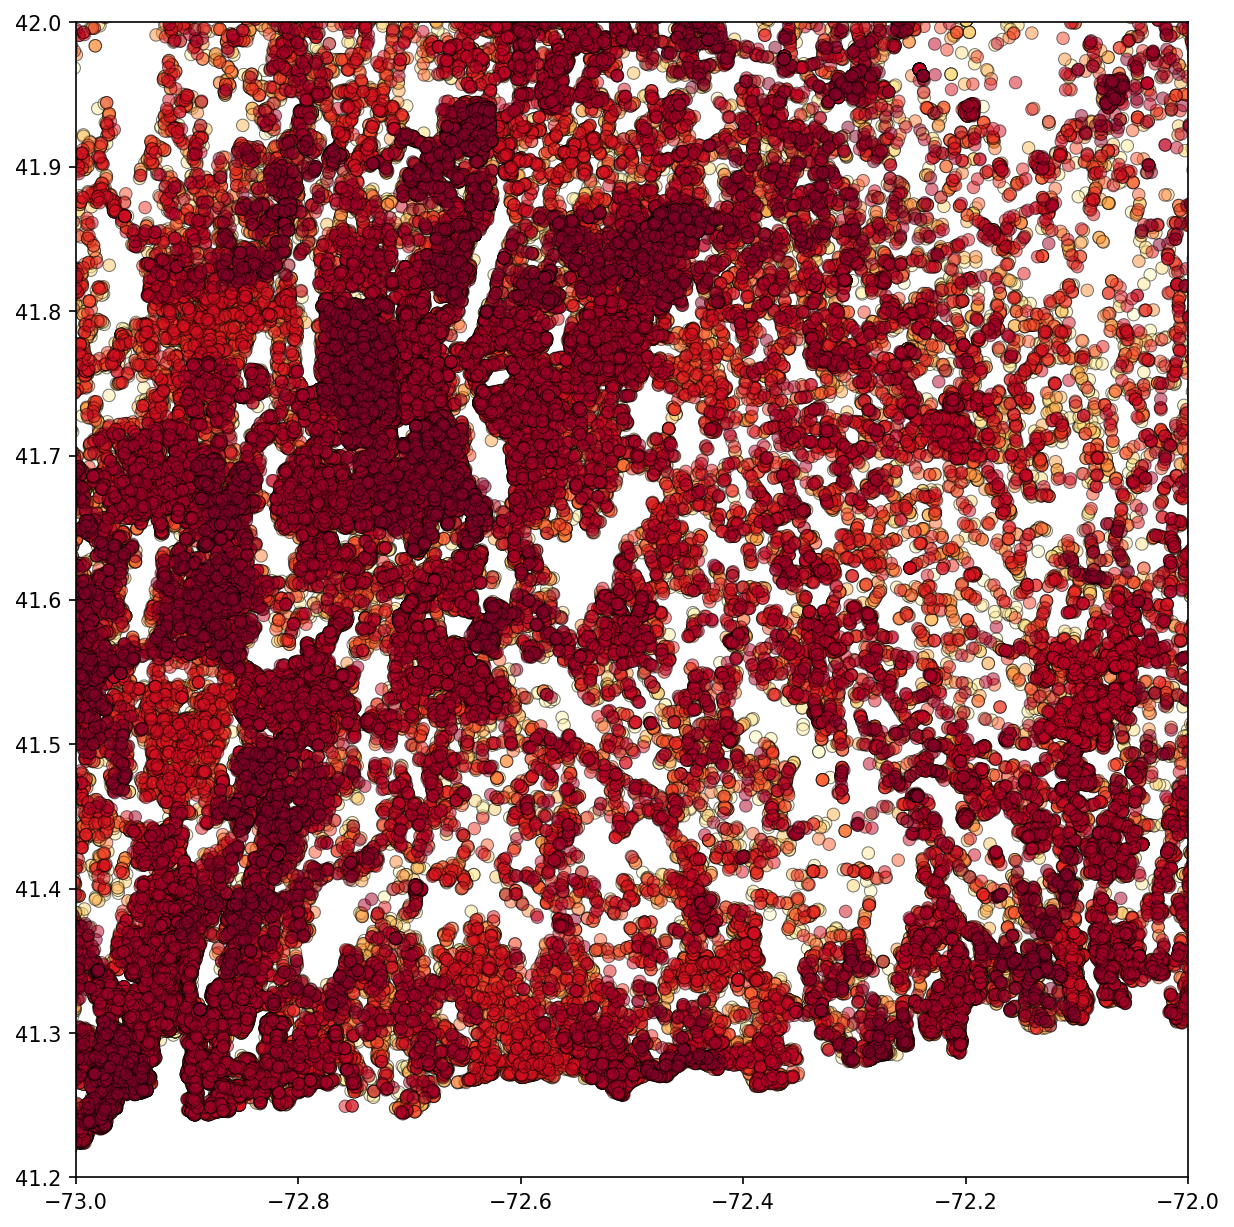

In [116]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim([-73, -72]) # Adjusted x-axis to cover the longitude range of your data
ax.set_ylim([41.2, 42]) # Adjusted y-axis to cover the latitude range of your data
gdf_clean_filtered_dates.plot(ax=ax, cmap='YlOrRd', alpha=0.5, edgecolor='black', linewidth=0.5)
plt.show()

In [130]:
gdf_2023 = gdf_clean_filtered_dates[gdf_clean_filtered_dates['Date Recorded'].dt.year == 2023]
gdf_single_2023 = gdf_2023[gdf_2023['Residential Type'] == 'Single Family']
gdf_single_2023

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,geometry
1054162,220060,2022,2023-01-03,East Windsor,108 RYE ST,108620.0,200000.0,0.5431,Residential,Single Family,01 - Family,,,POINT (-72.556613038 41.900422979),POINT (-72.55661 41.90042)
1054166,2200166,2022,2023-01-27,New Milford,28 BIRCHWOOD DR,168140.0,400000.0,0.4204,Residential,Single Family,,SALES RATIO,,POINT (-73.412279037 41.59633298),POINT (-73.41228 41.59633)
1054168,22211,2022,2023-04-28,Montville,41 CAROL DR,206410.0,355000.0,0.5814,Residential,Single Family,,,,POINT (-72.147517992 41.452868996),POINT (-72.14752 41.45287)
1054172,2222100,2022,2023-02-21,Ansonia,124 TREMONT ST,120960.0,105000.0,1.1520,Residential,Single Family,26 - Rehabilitation Deferred,SOLD OUT OF FCL WITHOUT REPAIRING,,POINT (-73.074479035 41.342346017),POINT (-73.07448 41.34235)
1054173,220249,2022,2023-01-17,Greenwich,110 SHEEPHILL ROAD,509600.0,700000.0,0.7280,Residential,Single Family,,,,POINT (-73.58336399 41.049459982),POINT (-73.58336 41.04946)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141700,2300031,2023,2023-11-08,Plymouth,7 HIGH ST,149660.0,309000.0,0.4843,Residential,Single Family,,,,POINT (-73.01386 41.67996),POINT (-73.01386 41.67996)
1141701,230030,2023,2023-10-20,Trumbull,31 WILSON AVE,229530.0,435000.0,0.5276,Residential,Single Family,,,,POINT (-73.1884 41.22293),POINT (-73.1884 41.22293)
1141710,2300019,2023,2023-11-14,Redding,101 PEACEABLE ST,404600.0,730000.0,0.5542,Residential,Single Family,,,,POINT (-73.4255 41.27485),POINT (-73.4255 41.27485)
1141711,230045,2023,2023-11-28,Trumbull,60 PARTRIDGE LN,346080.0,705000.0,0.4908,Residential,Single Family,07 - Change in Property,IMPROVED CONDITION,,POINT (-73.16685 41.2386),POINT (-73.16685 41.2386)


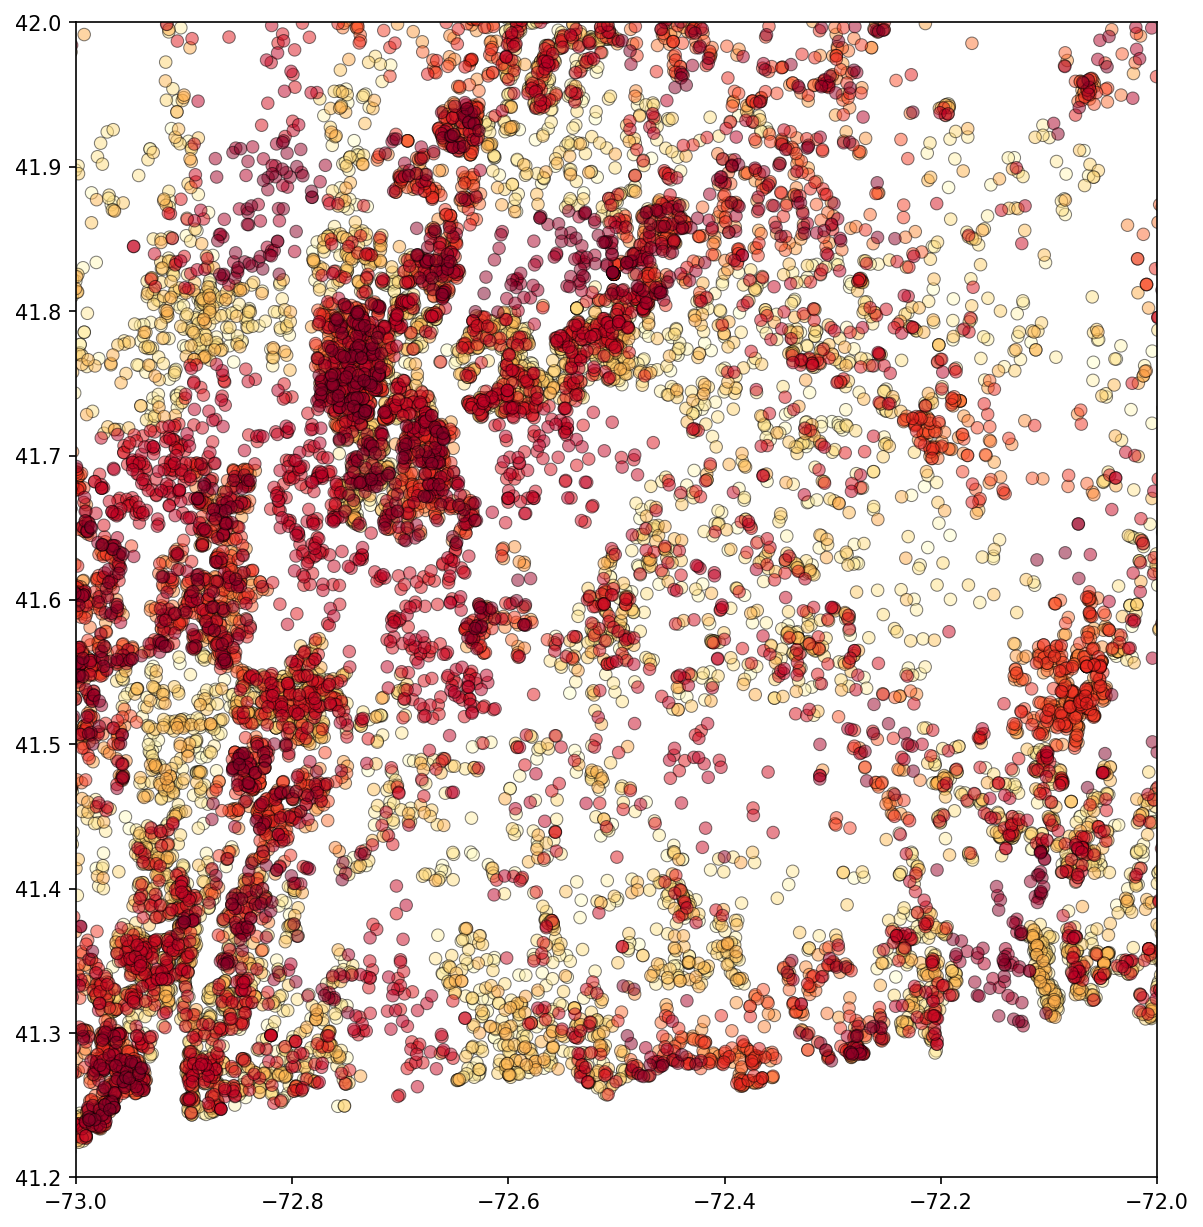

In [132]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim([-73, -72]) # Adjusted x-axis to cover the longitude range of your data
ax.set_ylim([41.2, 42]) # Adjusted y-axis to cover the latitude range of your data
gdf_single_2023.plot(ax=ax, cmap='YlOrRd', alpha=0.5, edgecolor='black', linewidth=0.5)
plt.show()